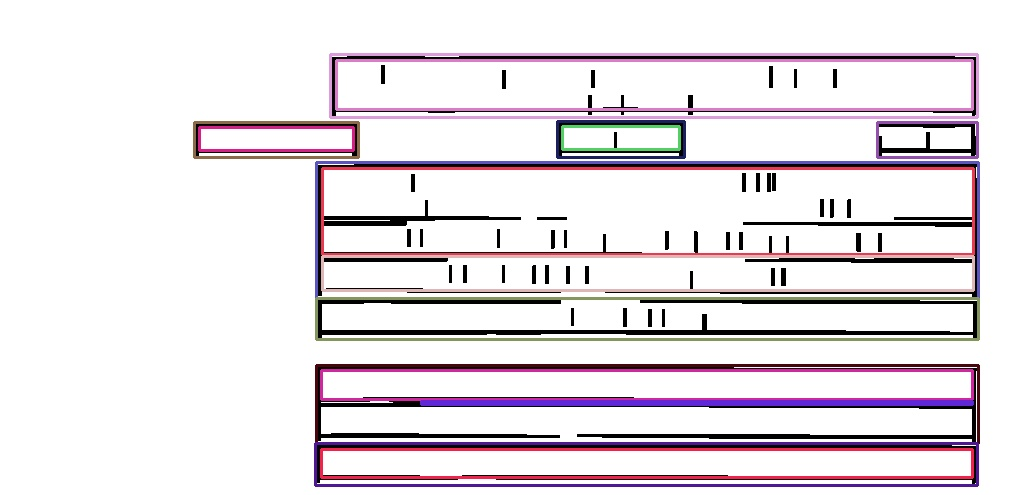

In [ ]:
import cv2
import numpy as np
import ipywidgets as widgets
from IPython.display import display, clear_output
from pathlib import Path
import random

# ======================= HELPER FUNCTIONS ===========================================
def sort_contours(cnts, method="left-to-right"):
    reverse = False
    i = 0
    if method == "right-to-left" or method == "bottom-to-top":
        reverse = True
    if method == "top-to-bottom" or method == "bottom-to-top":
        i = 1
    boundingBoxes = [cv2.boundingRect(c) for c in cnts]
    (cnts, boundingBoxes) = zip(*sorted(zip(cnts, boundingBoxes),
            key=lambda b:b[1][i], reverse=reverse))
    return (cnts, boundingBoxes)

# ======================= MAIN EXTRACTION FUNCTION ==================================
def box_extraction(img_path, h_val, v_val, min_area):
    # 1. Read and Preprocess
    img = cv2.imread(img_path, 0)
    # Using OTSU threshold
    (thresh, img_bin) = cv2.threshold(img, 128, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU)
    
    # Invert image (so lines are white on black background for morphology)
    img_bin = 255 - img_bin

    # 2. Create Kernels
    # Use a minimum size for kernels to prevent errors on tiny images
    kernel_length_horizont = max(h_val, 1)
    kernel_length_vertical = max(v_val, 1)

    verticle_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (1, kernel_length_vertical))
    hori_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (kernel_length_horizont, 1))
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (2, 2))

    # 3. Isolate Horizontal and Vertical lines (Your original method)
    # Note: Using Erode + Dilate to isolate lines, then subtracting/gathering them.
    img_temp1 = cv2.erode(img_bin, verticle_kernel, iterations=3)
    verticle_lines_img = cv2.dilate(img_temp1, verticle_kernel, iterations=3)

    img_temp2 = cv2.erode(img_bin, hori_kernel, iterations=3)
    horizontal_lines_img = cv2.dilate(img_temp2, hori_kernel, iterations=3)

    # 4. Combine lines to form boxes
    alpha = 0.5
    beta = 1.0 - alpha
    img_final_bin = cv2.addWeighted(verticle_lines_img, alpha, horizontal_lines_img, beta, 0.0)
    
    # Erode and threshold to clean up the grid
    img_final_bin = cv2.erode(~img_final_bin, kernel, iterations=2)
    (thresh, img_final_bin) = cv2.threshold(img_final_bin, 128, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU)

    # 5. FIND CONTOURS & EXTRACT INNER HOLES (COUNTERS)
    # RETR_TREE gives us the hierarchy to find the holes!
    contours, hierarchy = cv2.findContours(img_final_bin, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
    
    (contours, boundingBoxes) = sort_contours(contours, method="top-to-bottom")

    # Helper to visualize original image
    # img_color = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
    img_color = cv2.cvtColor(img_final_bin, cv2.COLOR_GRAY2BGR)
    
    inner_counters = []
    
    if hierarchy is not None:
        for i, c in enumerate(contours):
            # hierarchy[0][i][3] is the Parent Index
            parent_idx = hierarchy[0][i][3]
            
            # Filter 1: Must be an inner box (Has a parent)
            if parent_idx != -1:
                x, y, w, h = cv2.boundingRect(c)
                area = w * h
                
                # Filter 2: Must be larger than the min_area slider
                if area >= min_area:
                    inner_counters.append(c)
                    color = (random.randint(0, 255), random.randint(0, 255), random.randint(0, 255))
                    # Draw the counter in GREEN on the image for visualization
                    cv2.rectangle(img_color, (x, y), (x + w, y + h), color, 2)
                    
                    # === UNCOMMENT THE LINES BELOW TO SAVE CROPS ===
                    # crop = img[y:y+h, x:x+w]
                    # cv2.imwrite(f"./output/box_{i}.png", crop)

    # 6. DISPLAY RESULTS
    clear_output(wait=True) # Clear previous output so sliders don't duplicate
    display(widgets.VBox([slider_h, slider_v, slider_area]))
    
    # Convert BGR to RGB for Jupyter Notebook display
    img_rgb = cv2.cvtColor(img_color, cv2.COLOR_BGR2RGB)
    
    # Determine text to print
    print(f"Counters found: {len(inner_counters)}")
    print(f"Current params: H={h_val}, V={v_val}, MinArea={min_area}")
    
    from IPython.display import Image as IPImage
    import io
    # Convert OpenCV image to bytes to display inline
    is_success, buffer = cv2.imencode(".jpg", img_color)
    display(IPImage(data=buffer.tobytes()))

# ======================= SETUP SLIDERS ================================
# Create directories
Path("./output/").mkdir(parents=True, exist_ok=True)
Path("./inter_processing/").mkdir(parents=True, exist_ok=True)

# Create widgets
slider_h = widgets.IntSlider(value=6, min=1, max=80, step=1, description='Horiz Kernel:')
slider_v = widgets.IntSlider(value=6, min=1, max=80, step=1, description='Vert Kernel:')
slider_area = widgets.IntSlider(value=500, min=0, max=5000, step=50, description='Min Area (px):')

# ==================== BIND EVENTS ====================
def update_image(change):
    box_extraction(
        "/media/vadim/1TB_SSD/my_github/computer-vision-document-table-parser/input_images/1_rotate.jpg", 
        slider_h.value, 
        slider_v.value, 
        slider_area.value
    )

slider_h.observe(update_image, names='value')
slider_v.observe(update_image, names='value')
slider_area.observe(update_image, names='value')

# Initial run
update_image(None)